# CNN Hyperparameter Search

Train, test and visualize all search methods (manual, random, GA, PSO, ACO, Harmony Search) on every supported dataset (FashionMNIST, CIFAR10, CIFAR100).

## 1. Setup repo i środowiska

In [2]:
import os
from pathlib import Path

is_colab = os.getenv("COLAB_RELEASE_TAG") is not None

if is_colab:
    REPO_URL = "https://github.com/tsmyda/cnn-metaheuristics.git"
    PROJECT_DIR = Path("/content/cnn-metaheuristics")

    %cd /content
    !rm -rf {PROJECT_DIR}
    !git clone {REPO_URL} {PROJECT_DIR}
    %cd {PROJECT_DIR}
    !pip install -q -r requirements.txt
else:
    def find_project_root(start: Path) -> Path:
        for candidate in [start, *start.parents]:
            if (candidate / "src").exists() and (candidate / "requirements.txt").exists():
                return candidate
        raise RuntimeError(
            f"Could not locate project root from {start}. Run notebook from repo directory."
        )

    PROJECT_DIR = find_project_root(Path.cwd().resolve())
    os.chdir(PROJECT_DIR)

print("PROJECT_DIR:", PROJECT_DIR)

PROJECT_DIR: /home/jgrzes/cnn-metaheuristics


## 2. Importy

In [3]:
import sys
import importlib

sys.path.insert(0, str(PROJECT_DIR))

import torch
import pandas as pd
import matplotlib.pyplot as plt

import src.utils
import src.search_space
import src.evaluator
import src.plots
import src.report_tables
import src.algorithms.manual_search
import src.algorithms.random_search
import src.algorithms.ga
import src.algorithms.pso
import src.algorithms.aco
import src.algorithms.harmony_search

for mod in [
    src.utils,
    src.search_space,
    src.evaluator,
    src.plots,
    src.report_tables,
    src.algorithms.manual_search,
    src.algorithms.random_search,
    src.algorithms.ga,
    src.algorithms.pso,
    src.algorithms.aco,
    src.algorithms.harmony_search,
]:
    importlib.reload(mod)

from src.utils import set_seed, ensure_dir
from src.algorithms.manual_search import run_manual_search
from src.algorithms.random_search import run_random_search
from src.algorithms.ga import run_ga
from src.algorithms.pso import run_pso
from src.algorithms.aco import run_aco
from src.algorithms.harmony_search import run_harmony_search
from src.plots import (
    plot_best_so_far,
    plot_time_to_best,
    plot_hyperparam_metric_correlation_heatmaps_by_method,
    save_summary_table,
)
from src.report_tables import (
    save_method_summary,
    save_best_configs,
    save_time_to_best,
)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


## 3. Parametry eksperymentu

In [4]:
DATASETS = ["FashionMNIST", "CIFAR10", "CIFAR100"]

METHODS = [
    "manual_search",
    "random_search",
    "ga",
    "pso",
    "aco",
    "harmony_search",
]

SEED = 42
EPOCHS = 5

RANDOM_BUDGET = 20

GA_POPULATION = 5
GA_GENERATIONS = 4
GA_MUTATION_PROB = 0.20
GA_ELITE_SIZE = 1
GA_TOURNAMENT_SIZE = 3

PSO_SWARM = 5
PSO_ITERATIONS = 4
PSO_W = 0.7
PSO_C1 = 1.5
PSO_C2 = 1.5

ACO_ANTS = 5
ACO_ITERATIONS = 4
ACO_EVAPORATION = 0.2
ACO_Q = 1.0
ACO_TOP_K = 2

HS_MEMORY_SIZE = 5
HS_ITERATIONS = 15
HS_HMCR = 0.9
HS_PAR = 0.3

assert RANDOM_BUDGET == GA_POPULATION * GA_GENERATIONS, "GA budget should match random search budget"
assert RANDOM_BUDGET == PSO_SWARM * PSO_ITERATIONS, "PSO budget should match random search budget"
assert RANDOM_BUDGET == ACO_ANTS * ACO_ITERATIONS, "ACO budget should match random search budget"
assert RANDOM_BUDGET == HS_MEMORY_SIZE + HS_ITERATIONS, "HS budget should match random search budget"

RESULTS_DIR = os.path.join(PROJECT_DIR, "notebooks", "results")
TABLES_DIR = os.path.join(RESULTS_DIR, "tables")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")

ensure_dir(RESULTS_DIR)
ensure_dir(TABLES_DIR)
ensure_dir(FIGURES_DIR)

print("Datasets:", DATASETS)
print("Methods:", METHODS)
print("Seed:", SEED)
print("Epochs per evaluation:", EPOCHS)
print("Random budget:", RANDOM_BUDGET)
print("GA budget:", GA_POPULATION * GA_GENERATIONS)
print("PSO budget:", PSO_SWARM * PSO_ITERATIONS)
print("ACO budget:", ACO_ANTS * ACO_ITERATIONS)
print("HS budget:", HS_MEMORY_SIZE + HS_ITERATIONS)

Datasets: ['FashionMNIST', 'CIFAR10', 'CIFAR100']
Methods: ['manual_search', 'random_search', 'ga', 'pso', 'aco', 'harmony_search']
Seed: 42
Epochs per evaluation: 5
Random budget: 20
GA budget: 20
PSO budget: 20
ACO budget: 20
HS budget: 20


## 4. Sanity check losowania

In [5]:
from src.search_space import sample_config

for i in range(3):
    print(f"sample {i+1}:", sample_config())

sample 1: {'learning_rate': 0.0019004375238737116, 'batch_size': 32, 'num_blocks': 3, 'filters_1': 32, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.3682356070820062, 'dense_units': 256, 'optimizer': 'adamw', 'weight_decay': 0.0004748306046370143, 'use_batch_norm': 0}
sample 2: {'learning_rate': 0.0015169980582701848, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 16, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.2806225314693065, 'dense_units': 256, 'optimizer': 'adamw', 'weight_decay': 0.0001270500735408539, 'use_batch_norm': 1}
sample 3: {'learning_rate': 0.00027598230915285764, 'batch_size': 128, 'num_blocks': 1, 'filters_1': 16, 'filters_2': 128, 'filters_3': 128, 'kernel_size': 5, 'dropout': 0.13893567083582092, 'dense_units': 64, 'optimizer': 'sgd', 'weight_decay': 2.0259598275933324e-06, 'use_batch_norm': 1}


## 5. Pomocnicza funkcja: uruchom wszystkie metody na jednym zbiorze

In [6]:
def run_all_methods_for_dataset(dataset_name: str) -> pd.DataFrame:
    """Run every method in METHODS on a single dataset and return a combined DataFrame."""
    dfs = []

    if "manual_search" in METHODS:
        print(f"\n### [{dataset_name}] Manual search")
        _, df_manual = run_manual_search(
            dataset_name=dataset_name,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
        )
        dfs.append(df_manual)

    if "random_search" in METHODS:
        print(f"\n### [{dataset_name}] Random search")
        _, df_random = run_random_search(
            dataset_name=dataset_name,
            budget=RANDOM_BUDGET,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
        )
        dfs.append(df_random)

    if "ga" in METHODS:
        print(f"\n### [{dataset_name}] Genetic Algorithm")
        _, df_ga = run_ga(
            dataset_name=dataset_name,
            population_size=GA_POPULATION,
            generations=GA_GENERATIONS,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
            mutation_prob=GA_MUTATION_PROB,
            elite_size=GA_ELITE_SIZE,
            tournament_size=GA_TOURNAMENT_SIZE,
        )
        dfs.append(df_ga)

    if "pso" in METHODS:
        print(f"\n### [{dataset_name}] PSO")
        _, df_pso = run_pso(
            dataset_name=dataset_name,
            swarm_size=PSO_SWARM,
            iterations=PSO_ITERATIONS,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
            w=PSO_W,
            c1=PSO_C1,
            c2=PSO_C2,
        )
        dfs.append(df_pso)

    if "aco" in METHODS:
        print(f"\n### [{dataset_name}] ACO")
        _, df_aco = run_aco(
            dataset_name=dataset_name,
            ants=ACO_ANTS,
            iterations=ACO_ITERATIONS,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
            evaporation_rate=ACO_EVAPORATION,
            q=ACO_Q,
            top_k_deposit=ACO_TOP_K,
        )
        dfs.append(df_aco)

    if "harmony_search" in METHODS:
        print(f"\n### [{dataset_name}] Harmony Search")
        _, df_hs = run_harmony_search(
            dataset_name=dataset_name,
            harmony_memory_size=HS_MEMORY_SIZE,
            iterations=HS_ITERATIONS,
            epochs=EPOCHS,
            device=device,
            seed=SEED,
            hmcr=HS_HMCR,
            par=HS_PAR,
        )
        dfs.append(df_hs)

    df_all = pd.concat(dfs, ignore_index=True)
    df_all["dataset"] = dataset_name
    df_all["seed"] = SEED
    return df_all

## 6. Główna pętla: wszystkie metody x wszystkie zbiory

Uwaga: ten krok jest kosztowny. Dla każdego zbioru uruchamiamy 6 metod po ~20 ewaluacji.

In [6]:
results_per_dataset: dict[str, pd.DataFrame] = {}

for dataset_name in DATASETS:
    print(f"\n================ Dataset: {dataset_name} ================")
    set_seed(SEED)
    df_dataset = run_all_methods_for_dataset(dataset_name)

    dataset_csv = os.path.join(TABLES_DIR, f"all_methods_{dataset_name}.csv")
    df_dataset.to_csv(dataset_csv, index=False)
    results_per_dataset[dataset_name] = df_dataset
    print(f"Saved {dataset_name} results to {dataset_csv}")

df_all = pd.concat(results_per_dataset.values(), ignore_index=True)
all_csv = os.path.join(TABLES_DIR, "all_methods_all_datasets.csv")
df_all.to_csv(all_csv, index=False)
print("\nSaved combined results to", all_csv)
df_all[["dataset", "method", "iteration", "val_accuracy", "test_accuracy", "time_sec"]].head()


================ Dataset: FashionMNIST ================

### [FashionMNIST] Manual search
[MANUAL] iter=01/5 | val_acc=0.9212 | time=35.5s
[MANUAL] iter=02/5 | val_acc=0.9215 | time=25.7s
[MANUAL] iter=03/5 | val_acc=0.9197 | time=39.1s
[MANUAL] iter=04/5 | val_acc=0.9175 | time=58.3s
[MANUAL] iter=05/5 | val_acc=0.9218 | time=49.3s

### [FashionMNIST] Random search
[RS] iter=01/20 | val_acc=0.8908 | time=65.9s
[RS] iter=02/20 | val_acc=0.9160 | time=41.0s
[RS] iter=03/20 | val_acc=0.8652 | time=18.1s
[RS] iter=04/20 | val_acc=0.9172 | time=47.4s
[RS] iter=05/20 | val_acc=0.9017 | time=50.5s
[RS] iter=06/20 | val_acc=0.8967 | time=23.4s
[RS] iter=07/20 | val_acc=0.9182 | time=74.3s
[RS] iter=08/20 | val_acc=0.9148 | time=60.0s
[RS] iter=09/20 | val_acc=0.8932 | time=68.2s
[RS] iter=10/20 | val_acc=0.8675 | time=36.6s
[RS] iter=11/20 | val_acc=0.9170 | time=102.2s
[RS] iter=12/20 | val_acc=0.8510 | time=39.3s
[RS] iter=13/20 | val_acc=0.9140 | time=18.6s
[RS] iter=14/20 | val_acc=0.896

/home/jgrzes/cnn-metaheuristics/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[MANUAL] iter=01/5 | val_acc=0.7426 | time=22.7s
[MANUAL] iter=02/5 | val_acc=0.7360 | time=19.2s
[MANUAL] iter=03/5 | val_acc=0.7162 | time=28.9s
[MANUAL] iter=04/5 | val_acc=0.7372 | time=38.0s
[MANUAL] iter=05/5 | val_acc=0.6706 | time=35.2s

### [CIFAR10] Random search
[RS] iter=01/20 | val_acc=0.5388 | time=47.2s
[RS] iter=02/20 | val_acc=0.6720 | time=39.4s
[RS] iter=03/20 | val_acc=0.5296 | time=15.7s
[RS] iter=04/20 | val_acc=0.7232 | time=33.9s
[RS] iter=05/20 | val_acc=0.6238 | time=28.6s
[RS] iter=06/20 | val_acc=0.5828 | time=16.1s
[RS] iter=07/20 | val_acc=0.7320 | time=53.2s
[RS] iter=08/20 | val_acc=0.6568 | time=32.6s
[RS] iter=09/20 | val_acc=0.6386 | time=48.6s
[RS] iter=10/20 | val_acc=0.4104 | time=23.9s
[RS] iter=11/20 | val_acc=0.7330 | time=67.3s
[RS] iter=12/20 | val_acc=0.1014 | time=28.5s
[RS] iter=13/20 | val_acc=0.6546 | time=14.3s
[RS] iter=14/20 | val_acc=0.6310 | time=22.2s
[RS] iter=15/20 | val_acc=0.1014 | time=34.0s
[RS] iter=16/20 | val_acc=0.6234 | t

/home/jgrzes/cnn-metaheuristics/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


[MANUAL] iter=01/5 | val_acc=0.2112 | time=26.2s
[MANUAL] iter=02/5 | val_acc=0.3492 | time=22.1s
[MANUAL] iter=03/5 | val_acc=0.1816 | time=33.6s
[MANUAL] iter=04/5 | val_acc=0.3262 | time=38.2s
[MANUAL] iter=05/5 | val_acc=0.1898 | time=39.8s

### [CIFAR100] Random search
[RS] iter=01/20 | val_acc=0.0098 | time=58.8s
[RS] iter=02/20 | val_acc=0.2268 | time=40.1s
[RS] iter=03/20 | val_acc=0.1126 | time=16.1s
[RS] iter=04/20 | val_acc=0.3282 | time=36.9s
[RS] iter=05/20 | val_acc=0.1702 | time=41.5s
[RS] iter=06/20 | val_acc=0.2220 | time=18.6s
[RS] iter=07/20 | val_acc=0.2058 | time=52.8s
[RS] iter=08/20 | val_acc=0.0280 | time=41.0s
[RS] iter=09/20 | val_acc=0.2112 | time=53.2s
[RS] iter=10/20 | val_acc=0.0102 | time=35.9s
[RS] iter=11/20 | val_acc=0.0574 | time=66.2s
[RS] iter=12/20 | val_acc=0.0122 | time=26.0s
[RS] iter=13/20 | val_acc=0.3296 | time=14.2s
[RS] iter=14/20 | val_acc=0.2778 | time=20.2s
[RS] iter=15/20 | val_acc=0.1592 | time=38.4s
[RS] iter=16/20 | val_acc=0.2392 | 

,dataset,method,iteration,val_accuracy,test_accuracy,time_sec
0,FashionMNIST,manual_search,1,0.921167,0.9175,35.489305
1,FashionMNIST,manual_search,2,0.921500,0.9180,25.710423
2,FashionMNIST,manual_search,3,0.919667,0.9153,39.122279
3,FashionMNIST,manual_search,4,0.917500,0.9114,58.294441
4,FashionMNIST,manual_search,5,0.921833,0.9176,49.284725


In [18]:
# Rebuild `results_per_dataset` and `df_all` from saved CSVs
import os
import pandas as pd

TABLES_DIR = os.path.join(PROJECT_DIR, "notebooks", "results", "tables")
results_per_dataset = {}

all_path = os.path.join(TABLES_DIR, "all_methods_all_datasets.csv")
if os.path.exists(all_path):
    df_all = pd.read_csv(all_path)
    # also populate per-dataset dict if per-dataset files exist
    for ds in DATASETS:
        p = os.path.join(TABLES_DIR, f"all_methods_{ds}.csv")
        if os.path.exists(p):
            results_per_dataset[ds] = pd.read_csv(p)
        else:
            print("Brak pliku per-dataset (opcjonalne):", p)
else:
    # fallback: read per-dataset files and concatenate
    for ds in DATASETS:
        p = os.path.join(TABLES_DIR, f"all_methods_{ds}.csv")
        if os.path.exists(p):
            results_per_dataset[ds] = pd.read_csv(p)
        else:
            print("Brak pliku:", p)
    if results_per_dataset:
        df_all = pd.concat(results_per_dataset.values(), ignore_index=True)
        df_all.to_csv(all_path, index=False)
        print("Zbudowano i zapisano:", all_path)
    else:
        raise FileNotFoundError(f"No result CSVs found in {TABLES_DIR}")

print("Loaded datasets:", list(results_per_dataset.keys()))
print("df_all rows:", len(df_all))

Loaded datasets: ['FashionMNIST', 'CIFAR10', 'CIFAR100']
df_all rows: 315


## 7. Wykresy best-so-far per zbiór danych

Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/best_so_far_FashionMNIST.png
Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/best_so_far_CIFAR10.png
Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/best_so_far_CIFAR100.png


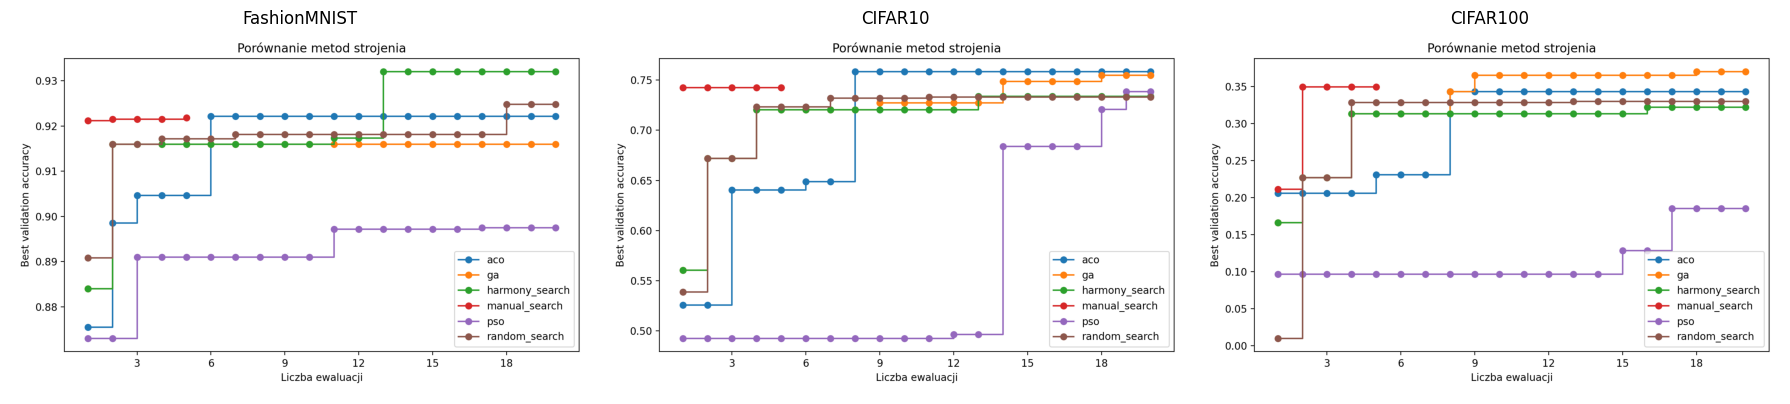

In [9]:
best_so_far_paths = {}

for dataset_name, df_dataset in results_per_dataset.items():
    dataset_csv = os.path.join(TABLES_DIR, f"all_methods_{dataset_name}.csv")
    fig_path = os.path.join(FIGURES_DIR, f"best_so_far_{dataset_name}.png")
    plot_best_so_far(dataset_csv, fig_path)
    best_so_far_paths[dataset_name] = fig_path
    print("Saved:", fig_path)

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5))
if len(DATASETS) == 1:
    axes = [axes]
for ax, dataset_name in zip(axes, DATASETS):
    img = plt.imread(best_so_far_paths[dataset_name])
    ax.imshow(img)
    ax.set_title(dataset_name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Wykresy time-to-best per zbiór danych

In [10]:
time_to_best_per_dataset = {}

for dataset_name, df_dataset in results_per_dataset.items():
    ttb_csv = os.path.join(TABLES_DIR, f"time_to_best_{dataset_name}.csv")
    ttb_df = save_time_to_best(df_dataset, ttb_csv)
    time_to_best_per_dataset[dataset_name] = ttb_df

    fig_path = os.path.join(FIGURES_DIR, f"time_to_best_{dataset_name}.png")
    plot_time_to_best(ttb_df, fig_path)
    print("Saved:", fig_path)

pd.concat(
    [df.assign(dataset=name) for name, df in time_to_best_per_dataset.items()],
    ignore_index=True,
)

Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/time_to_best_FashionMNIST.png
Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/time_to_best_CIFAR10.png
Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/time_to_best_CIFAR100.png


,method,best_val_accuracy,test_accuracy_at_best,iteration_of_best,time_of_best_sec,total_time_sec,dataset
0,harmony_search,0.932000,0.9226,13,473.988400,630.750625,FashionMNIST
1,random_search,0.924833,0.9184,18,834.147286,929.553982,FashionMNIST
2,aco,0.922167,0.9155,6,161.670436,620.712517,FashionMNIST
3,manual_search,0.921833,0.9176,5,207.901172,207.901172,FashionMNIST
4,ga,0.916000,0.9122,2,98.245722,785.151822,FashionMNIST
5,pso,0.897500,0.8929,17,463.165316,555.859145,FashionMNIST
6,aco,0.758200,0.7605,8,177.607344,468.843518,CIFAR10
7,ga,0.754800,0.7513,18,665.168819,744.651419,CIFAR10
8,manual_search,0.742600,0.7365,1,22.686777,143.918696,CIFAR10
9,pso,0.738400,0.7390,19,518.277341,545.800091,CIFAR10


## 9. Hyperparameter correlation heatmaps (per zbiór danych, per metoda)

In [11]:
for dataset_name, df_dataset in results_per_dataset.items():
    out_dir = os.path.join(FIGURES_DIR, f"hyperparam_correlations_{dataset_name}")
    plot_hyperparam_metric_correlation_heatmaps_by_method(df_dataset, out_dir)
    print("Saved heatmaps for", dataset_name, "to", out_dir)

Saved heatmaps for FashionMNIST to /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/hyperparam_correlations_FashionMNIST
Saved heatmaps for CIFAR10 to /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/hyperparam_correlations_CIFAR10
Saved heatmaps for CIFAR100 to /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/hyperparam_correlations_CIFAR100


## 10. Tabele podsumowujące (per zbiór danych)

In [12]:
summaries = {}
for dataset_name, df_dataset in results_per_dataset.items():
    summary_path = os.path.join(TABLES_DIR, f"method_summary_{dataset_name}.csv")
    summary = save_method_summary(df_dataset, summary_path)
    summaries[dataset_name] = summary
    print(f"\n=== {dataset_name} ===")
    display(summary)


=== FashionMNIST ===


val_accuracy                 test_accuracy                  \
                        max    mean     std           max    mean     std   
method                                                                      
aco                  0.9222  0.8960  0.0189        0.9155  0.8915  0.0197   
ga                   0.9160  0.9087  0.0129        0.9132  0.9048  0.0124   
harmony_search       0.9320  0.8828  0.0540        0.9226  0.8788  0.0542   
manual_search        0.9218  0.9203  0.0018        0.9180  0.9160  0.0028   
pso                  0.8975  0.8023  0.2399        0.8929  0.7964  0.2385   
random_search        0.9248  0.8925  0.0343        0.9184  0.8874  0.0329   

                time_sec                   num_params                          
                     max     mean      std        max       mean          std  
method                                                                         
aco              63.4248  31.0356  14.3725    3318218   871062.8  786792.0993  
ga               55.9822  39.2576  10.3858    3251914   978718.8  787227.7236  
harmony_search   66.1215  31.5375  16.2767    3251914   959838.0  990453.1618  
manual_search    58.2944  41.5802  12.5869    1738698   868989.2  525782.5318  
pso              52.4509  27.7930   9.6212    1634922   918198.8  459348.6163  
random_search   102.1625  46.4777  20.6116    3251658  1192659.6  859899.8155


=== CIFAR10 ===


val_accuracy                 test_accuracy                  \
                        max    mean     std           max    mean     std   
method                                                                      
aco                  0.7582  0.5797  0.1246        0.7605  0.5781  0.1234   
ga                   0.7548  0.6510  0.1074        0.7513  0.6524  0.1053   
harmony_search       0.7338  0.5240  0.1965        0.7384  0.5257  0.1966   
manual_search        0.7426  0.7205  0.0296        0.7379  0.7181  0.0285   
pso                  0.7384  0.3636  0.2476        0.7390  0.3642  0.2500   
random_search        0.7330  0.5465  0.1949        0.7267  0.5471  0.1944   

               time_sec                   num_params                           
                    max     mean      std        max       mean           std  
method                                                                         
aco             45.2362  23.4422   8.4816    4304458   868851.6  1.055253e+06  
ga              46.7073  37.2326   8.1290    2450026  1031802.8  7.574412e+05  
harmony_search  56.1894  29.4046  14.8758    4235850   903775.6  9.498169e+05  
manual_search   37.9881  28.7837   7.9789    2198602  1107453.2  6.645914e+05  
pso             49.8725  27.2900   8.4867    1060266   628162.0  1.378929e+05  
random_search   67.2963  33.3662  13.9007    4235850  1437587.6  1.010667e+06


=== CIFAR100 ===


val_accuracy                 test_accuracy                  \
                        max    mean     std           max    mean     std   
method                                                                      
aco                  0.3430  0.1816  0.1096        0.3421  0.1811  0.1110   
ga                   0.3698  0.2542  0.1113        0.3725  0.2540  0.1089   
harmony_search       0.3220  0.1796  0.1089        0.3214  0.1808  0.1100   
manual_search        0.3492  0.2516  0.0798        0.3563  0.2521  0.0818   
pso                  0.1850  0.0554  0.0608        0.1912  0.0546  0.0615   
random_search        0.3296  0.1576  0.1139        0.3374  0.1571  0.1144   

               time_sec                   num_params                           
                    max     mean      std        max       mean           std  
method                                                                         
aco             42.0907  23.5195   7.3386    4327588  1022621.6  1.056216e+06  
ga              49.8283  35.2893   9.5846    2461636   993108.8  6.724665e+05  
harmony_search  41.2269  23.7145   9.0480    2461636   905724.0  6.779705e+05  
manual_search   39.7766  31.9552   7.6401    2221732  1123671.2  6.693755e+05  
pso             56.8415  28.0122  11.0768    1071876   571276.0  1.761253e+05  
random_search   66.1839  36.6050  14.2313    4258980  1449773.6  1.012034e+06

## 11. Najlepsze konfiguracje na każdy zbiór danych x metodę

In [13]:
best_configs_per_dataset = {}
for dataset_name, df_dataset in results_per_dataset.items():
    best_path = os.path.join(TABLES_DIR, f"best_configs_{dataset_name}.csv")
    best_df = save_best_configs(df_dataset, best_path)
    best_configs_per_dataset[dataset_name] = best_df
    print(f"\n=== Best per method on {dataset_name} ===")
    display(best_df[[
        "method",
        "iteration",
        "learning_rate",
        "batch_size",
        "num_blocks",
        "filters_1",
        "filters_2",
        "filters_3",
        "kernel_size",
        "dropout",
        "dense_units",
        "val_accuracy",
        "test_accuracy",
        "time_sec",
        "num_params",
    ]])


=== Best per method on FashionMNIST ===


,method,iteration,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy,test_accuracy,time_sec,num_params
0,harmony_search,13,0.001428,32,3,64,32,128,3,0.030306,256,0.932000,0.9226,66.121465,548490
1,random_search,18,0.002080,128,2,32,64,256,3,0.336682,256,0.924833,0.9184,25.516878,871018
2,aco,6,0.001000,256,2,32,64,256,5,0.100000,128,0.922167,0.9155,27.151286,583402
3,manual_search,5,0.000800,32,1,32,64,128,5,0.200000,128,0.921833,0.9176,49.284725,830826
4,ga,2,0.001517,32,1,16,32,64,3,0.280623,256,0.916000,0.9122,42.263525,808186
5,pso,17,0.003750,128,1,32,32,64,5,0.193395,256,0.897500,0.8929,21.227181,1634922



=== Best per method on CIFAR10 ===


,method,iteration,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy,test_accuracy,time_sec,num_params
0,aco,8,0.001000,128,2,64,32,64,3,0.000000,64,0.7582,0.7605,22.053813,198602
1,ga,18,0.000156,64,3,64,64,64,5,0.268114,64,0.7548,0.7513,44.627778,584202
2,manual_search,1,0.001000,64,2,32,64,128,3,0.250000,128,0.7426,0.7365,22.686777,591658
3,pso,19,0.001403,32,2,64,64,64,3,0.088862,128,0.7384,0.7390,40.370858,638794
4,harmony_search,13,0.001428,32,3,64,32,64,3,0.368236,256,0.7338,0.7384,53.242011,387466
5,random_search,11,0.002294,32,3,64,64,256,5,0.055776,128,0.7330,0.7267,67.296348,2888010



=== Best per method on CIFAR100 ===


,method,iteration,learning_rate,batch_size,num_blocks,filters_1,filters_2,filters_3,kernel_size,dropout,dense_units,val_accuracy,test_accuracy,time_sec,num_params
0,ga,18,0.000156,64,3,64,64,64,5,0.268114,128,0.3698,0.3725,43.498296,662052
1,manual_search,2,0.000500,128,2,32,64,128,3,0.300000,256,0.3492,0.3563,22.083797,1140484
2,aco,8,0.001000,64,1,64,64,64,3,0.000000,64,0.3430,0.3421,22.078804,1094116
3,random_search,13,0.001577,256,1,16,64,128,3,0.028963,256,0.3296,0.3374,14.150516,1077364
4,harmony_search,16,0.001517,128,1,16,32,64,3,0.030306,256,0.3220,0.3136,18.439440,1077300
5,pso,17,0.002729,128,3,64,64,128,3,0.243250,64,0.1850,0.1912,23.294050,471652


## 12. Wykres jakość vs skumulowany czas

In [14]:
def plot_best_so_far_vs_time(df: pd.DataFrame, output_path: str, title: str) -> None:
    plt.figure(figsize=(8, 5))
    for method, group in df.groupby("method"):
        group = group.sort_values("iteration").copy()
        group["cum_time_sec"] = group["time_sec"].cumsum()
        group["best_so_far"] = group["val_accuracy"].cummax()
        plt.plot(group["cum_time_sec"], group["best_so_far"], label=method)
    plt.xlabel("Skumulowany czas [s]")
    plt.ylabel("Best validation accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

for dataset_name, df_dataset in results_per_dataset.items():
    fig_path = os.path.join(FIGURES_DIR, f"best_so_far_vs_time_{dataset_name}.png")
    plot_best_so_far_vs_time(df_dataset, fig_path, f"Quality vs cumulative time - {dataset_name}")
    print("Saved:", fig_path)

Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/best_so_far_vs_time_FashionMNIST.png
Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/best_so_far_vs_time_CIFAR10.png
Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/best_so_far_vs_time_CIFAR100.png


## 13. Cross-dataset: najlepsza val_accuracy per metoda x zbiór

Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/tables/cross_dataset_best_val_accuracy.csv


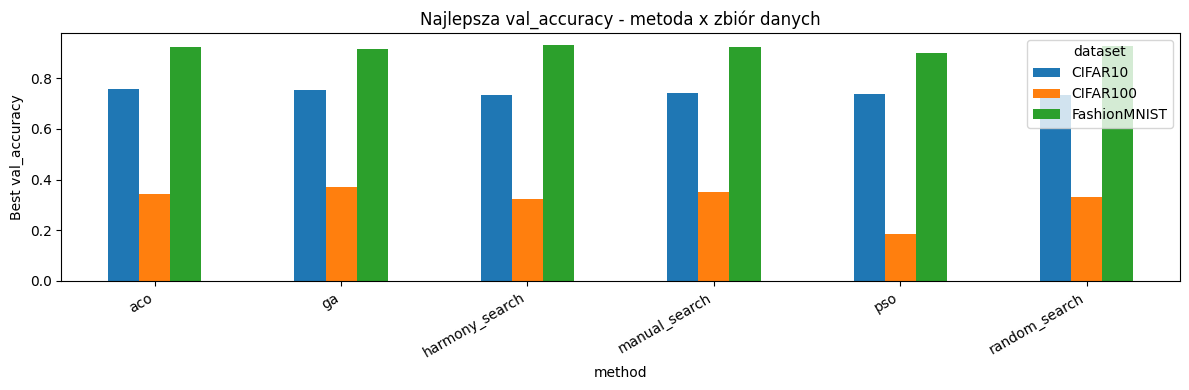

Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/cross_dataset_best_val_accuracy.png


dataset,CIFAR10,CIFAR100,FashionMNIST
method,,,
aco,0.7582,0.3430,0.9222
ga,0.7548,0.3698,0.9160
harmony_search,0.7338,0.3220,0.9320
manual_search,0.7426,0.3492,0.9218
pso,0.7384,0.1850,0.8975
random_search,0.7330,0.3296,0.9248


In [19]:
cross = (
    df_all.groupby(["dataset", "method"])["val_accuracy"].max().unstack("dataset").round(4)
)
cross_path = os.path.join(TABLES_DIR, "cross_dataset_best_val_accuracy.csv")
cross.to_csv(cross_path)
print("Saved:", cross_path)

fig, ax = plt.subplots(figsize=(1.5 * len(METHODS) + 3, 4))
cross.plot(kind="bar", ax=ax)
ax.set_ylabel("Best val_accuracy")
ax.set_title("Najlepsza val_accuracy - metoda x zbiór danych")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
cross_fig_path = os.path.join(FIGURES_DIR, "cross_dataset_best_val_accuracy.png")
plt.savefig(cross_fig_path, dpi=200)
plt.show()
print("Saved:", cross_fig_path)
cross

## 14. Final retraining najlepszych konfiguracji

Dla każdej pary (zbiór danych, metoda) bierzemy najlepszą konfigurację ze stage'u wyszukiwania i dotrenowujemy ją na większej liczbie epok.

In [20]:
FINAL_EPOCHS = 20
FINAL_SEED = 42

print("Final retraining epochs:", FINAL_EPOCHS)

Final retraining epochs: 20


In [21]:
from src.datasets import get_dataset_loaders
from src.model import TunableCNN
from src.train import train_one_epoch, evaluate
from src.utils import count_parameters
from torch.optim import Adam


def retrain_best_config(
    config: dict,
    dataset_name: str,
    epochs: int,
    device: str,
    seed: int = 42,
    val_split: float = 0.1,
    num_workers: int = 2,
):
    import numpy as np
    import torch

    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    train_loader, val_loader, test_loader, image_channels, image_size, num_classes = get_dataset_loaders(
        dataset_name=dataset_name,
        batch_size=int(config["batch_size"]),
        val_split=val_split,
        num_workers=num_workers,
        seed=seed,
    )

    model = TunableCNN(
        image_channels=image_channels,
        image_size=image_size,
        num_classes=num_classes,
        num_blocks=int(config["num_blocks"]),
        filters_1=int(config["filters_1"]),
        filters_2=int(config["filters_2"]),
        filters_3=int(config["filters_3"]),
        kernel_size=int(config["kernel_size"]),
        dropout=float(config["dropout"]),
        use_batch_norm=int(config.get("use_batch_norm", 1)),
        dense_units=int(config["dense_units"]),
    ).to(device)

    optimizer = Adam(model.parameters(), lr=float(config["learning_rate"]))

    history = []
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, device)

    return {
        "best_val_acc_retrain": best_val_acc,
        "final_test_acc": test_acc,
        "final_test_loss": test_loss,
        "num_params": count_parameters(model),
        "history": pd.DataFrame(history),
    }

In [22]:
final_results = []
history_frames = []

for dataset_name, best_df in best_configs_per_dataset.items():
    for _, row in best_df.iterrows():
        method = row["method"]
        config = {
            "learning_rate": row["learning_rate"],
            "batch_size": row["batch_size"],
            "num_blocks": row["num_blocks"],
            "filters_1": row["filters_1"],
            "filters_2": row["filters_2"],
            "filters_3": row["filters_3"],
            "kernel_size": row["kernel_size"],
            "dropout": row["dropout"],
            "dense_units": row["dense_units"],
        }

        print(f"\n=== Final retraining: {dataset_name} / {method} ===")
        print(config)

        out = retrain_best_config(
            config=config,
            dataset_name=dataset_name,
            epochs=FINAL_EPOCHS,
            device=device,
            seed=FINAL_SEED,
        )

        final_results.append({
            "dataset": dataset_name,
            "method": method,
            "search_best_val_accuracy": row["val_accuracy"],
            "search_test_accuracy": row["test_accuracy"],
            "retrain_best_val_accuracy": out["best_val_acc_retrain"],
            "final_test_accuracy": out["final_test_acc"],
            "final_test_loss": out["final_test_loss"],
            "num_params": out["num_params"],
        })

        hist = out["history"].copy()
        hist["dataset"] = dataset_name
        hist["method"] = method
        history_frames.append(hist)

final_results_df = pd.DataFrame(final_results).sort_values(
    ["dataset", "final_test_accuracy"], ascending=[True, False]
)
final_history_df = pd.concat(history_frames, ignore_index=True)

final_results_df


=== Final retraining: FashionMNIST / harmony_search ===
{'learning_rate': 0.0014279213611219, 'batch_size': 32, 'num_blocks': 3, 'filters_1': 64, 'filters_2': 32, 'filters_3': 128, 'kernel_size': 3, 'dropout': 0.0303063370385068, 'dense_units': 256}

=== Final retraining: FashionMNIST / random_search ===
{'learning_rate': 0.0020795314796063, 'batch_size': 128, 'num_blocks': 2, 'filters_1': 32, 'filters_2': 64, 'filters_3': 256, 'kernel_size': 3, 'dropout': 0.3366822736466507, 'dense_units': 256}

=== Final retraining: FashionMNIST / aco ===
{'learning_rate': 0.001, 'batch_size': 256, 'num_blocks': 2, 'filters_1': 32, 'filters_2': 64, 'filters_3': 256, 'kernel_size': 5, 'dropout': 0.1, 'dense_units': 128}

=== Final retraining: FashionMNIST / manual_search ===
{'learning_rate': 0.0008, 'batch_size': 32, 'num_blocks': 1, 'filters_1': 32, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 5, 'dropout': 0.2, 'dense_units': 128}

=== Final retraining: FashionMNIST / ga ===
{'learning_rate':

/home/jgrzes/cnn-metaheuristics/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



=== Final retraining: CIFAR10 / ga ===
{'learning_rate': 0.0001561107296769, 'batch_size': 64, 'num_blocks': 3, 'filters_1': 64, 'filters_2': 64, 'filters_3': 64, 'kernel_size': 5, 'dropout': 0.2681140457273503, 'dense_units': 64}

=== Final retraining: CIFAR10 / manual_search ===
{'learning_rate': 0.001, 'batch_size': 64, 'num_blocks': 2, 'filters_1': 32, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 3, 'dropout': 0.25, 'dense_units': 128}

=== Final retraining: CIFAR10 / pso ===
{'learning_rate': 0.0014031324186688, 'batch_size': 32, 'num_blocks': 2, 'filters_1': 64, 'filters_2': 64, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.0888616782475975, 'dense_units': 128}

=== Final retraining: CIFAR10 / harmony_search ===
{'learning_rate': 0.0014279213611219, 'batch_size': 32, 'num_blocks': 3, 'filters_1': 64, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.3682356070820062, 'dense_units': 256}

=== Final retraining: CIFAR10 / random_search ===
{'learning_rate': 0.

/home/jgrzes/cnn-metaheuristics/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



=== Final retraining: CIFAR100 / manual_search ===
{'learning_rate': 0.0005, 'batch_size': 128, 'num_blocks': 2, 'filters_1': 32, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 3, 'dropout': 0.3, 'dense_units': 256}

=== Final retraining: CIFAR100 / aco ===
{'learning_rate': 0.001, 'batch_size': 64, 'num_blocks': 1, 'filters_1': 64, 'filters_2': 64, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.0, 'dense_units': 64}

=== Final retraining: CIFAR100 / random_search ===
{'learning_rate': 0.0015772087178392, 'batch_size': 256, 'num_blocks': 1, 'filters_1': 16, 'filters_2': 64, 'filters_3': 128, 'kernel_size': 3, 'dropout': 0.0289625832470937, 'dense_units': 256}

=== Final retraining: CIFAR100 / harmony_search ===
{'learning_rate': 0.0015169980582701, 'batch_size': 128, 'num_blocks': 1, 'filters_1': 16, 'filters_2': 32, 'filters_3': 64, 'kernel_size': 3, 'dropout': 0.0303063370385068, 'dense_units': 256}

=== Final retraining: CIFAR100 / pso ===
{'learning_rate': 0.0027289951573245, 

,dataset,method,search_best_val_accuracy,search_test_accuracy,retrain_best_val_accuracy,final_test_accuracy,final_test_loss,num_params
7,CIFAR10,ga,0.754800,0.7513,0.850000,0.8503,0.456511,584202
11,CIFAR10,random_search,0.733000,0.7267,0.831000,0.8244,0.867504,2888010
10,CIFAR10,harmony_search,0.733800,0.7384,0.821000,0.8140,0.542953,387466
9,CIFAR10,pso,0.738400,0.7390,0.807800,0.8011,0.681344,638794
8,CIFAR10,manual_search,0.742600,0.7365,0.806200,0.7996,0.589196,591658
6,CIFAR10,aco,0.758200,0.7605,0.777400,0.7749,0.726663,198602
12,CIFAR100,ga,0.369800,0.3725,0.515400,0.5189,1.763361,662052
13,CIFAR100,manual_search,0.349200,0.3563,0.472600,0.4666,1.976654,1140484
17,CIFAR100,pso,0.185000,0.1912,0.380800,0.3850,2.309157,472676
15,CIFAR100,random_search,0.329600,0.3374,0.329400,0.3437,2.774818,1077364


## 15. Zapis wyników finalnego retrainingu

In [23]:
final_results_path = os.path.join(TABLES_DIR, "final_retraining_results.csv")
final_history_path = os.path.join(TABLES_DIR, "final_retraining_history.csv")

final_results_df.to_csv(final_results_path, index=False)
final_history_df.to_csv(final_history_path, index=False)

print("Saved final retraining results to:", final_results_path)
print("Saved final retraining history to:", final_history_path)

Saved final retraining results to: /home/jgrzes/cnn-metaheuristics/notebooks/results/tables/final_retraining_results.csv
Saved final retraining history to: /home/jgrzes/cnn-metaheuristics/notebooks/results/tables/final_retraining_history.csv


## 16. Wykresy finalnego treningu (per zbiór danych)

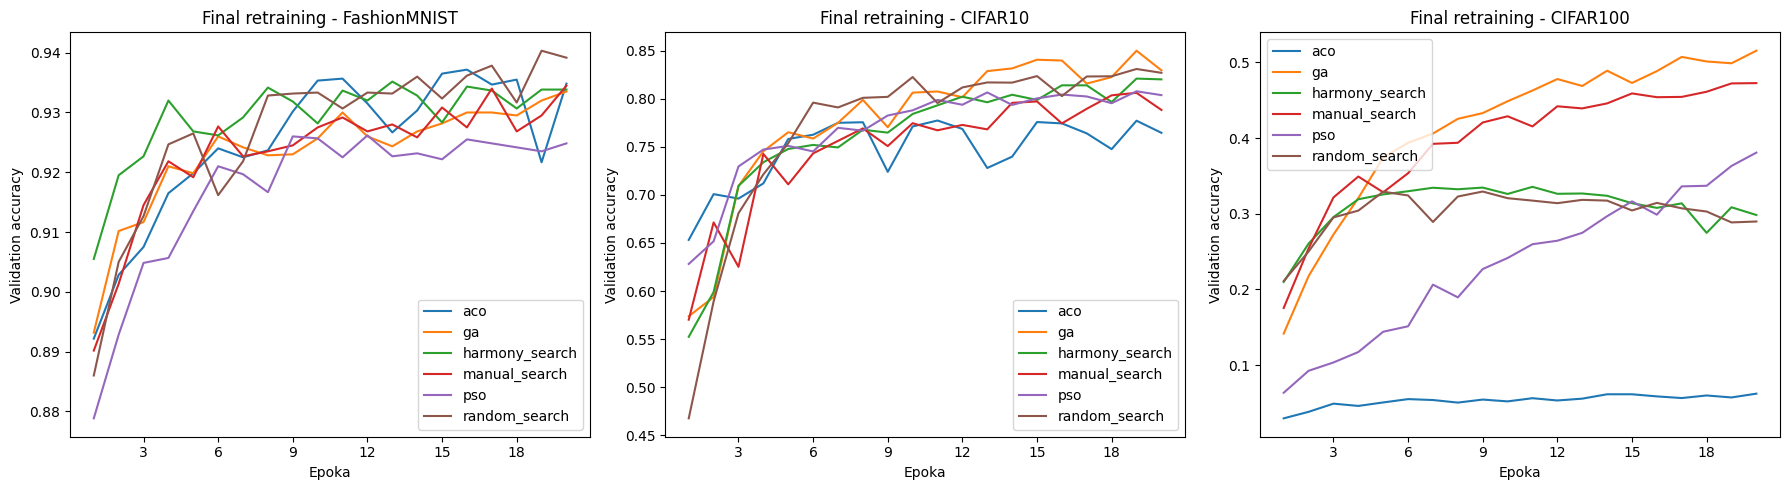

Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/final_retraining_val_curves.png


In [27]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5), sharey=False)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset_name in zip(axes, DATASETS):
    subset = final_history_df[final_history_df["dataset"] == dataset_name]
    for method, group in subset.groupby("method"):
        ax.plot(group["epoch"], group["val_acc"], label=method)
    
    ax.set_title(f"Final retraining - {dataset_name}")
    ax.set_xlabel("Epoka")
    ax.set_ylabel("Validation accuracy")
    
    # 2. Ta linijka wymusza tylko liczby całkowite na osi X
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    ax.legend()

plt.tight_layout()
final_curves_path = os.path.join(FIGURES_DIR, "final_retraining_val_curves.png")
plt.savefig(final_curves_path, dpi=200)
plt.show()
print("Saved:", final_curves_path)

## 17. Final test accuracy - metoda x zbiór danych

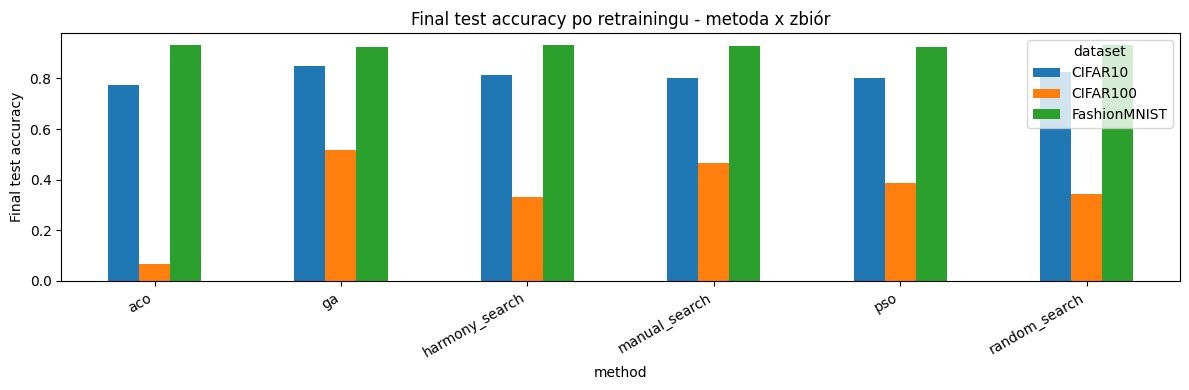

Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/tables/final_test_accuracy_pivot.csv
Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/figures/final_test_accuracy_pivot.png


dataset,CIFAR10,CIFAR100,FashionMNIST
method,,,
aco,0.7749,0.0678,0.9320
ga,0.8503,0.5189,0.9253
harmony_search,0.8140,0.3323,0.9305
manual_search,0.7996,0.4666,0.9268
pso,0.8011,0.3850,0.9226
random_search,0.8244,0.3437,0.9331


In [25]:
final_pivot = (
    final_results_df.pivot(index="method", columns="dataset", values="final_test_accuracy").round(4)
)
final_pivot_path = os.path.join(TABLES_DIR, "final_test_accuracy_pivot.csv")
final_pivot.to_csv(final_pivot_path)

fig, ax = plt.subplots(figsize=(1.5 * len(METHODS) + 3, 4))
final_pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Final test accuracy")
ax.set_title("Final test accuracy po retrainingu - metoda x zbiór")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
final_pivot_fig_path = os.path.join(FIGURES_DIR, "final_test_accuracy_pivot.png")
plt.savefig(final_pivot_fig_path, dpi=200)
plt.show()
print("Saved:", final_pivot_path)
print("Saved:", final_pivot_fig_path)
final_pivot

## 18. Końcowa tabela do raportu

In [26]:
analysis_rows = []
for dataset_name, df_dataset in results_per_dataset.items():
    agg = (
        df_dataset.groupby("method", as_index=False)
        .agg(
            best_val_accuracy=("val_accuracy", "max"),
            mean_val_accuracy=("val_accuracy", "mean"),
            best_test_accuracy=("test_accuracy", "max"),
            mean_time_sec=("time_sec", "mean"),
            total_time_sec=("time_sec", "sum"),
            mean_num_params=("num_params", "mean"),
        )
    )
    agg["dataset"] = dataset_name
    analysis_rows.append(agg)

analysis_df = pd.concat(analysis_rows, ignore_index=True)

report_table = final_results_df.merge(
    analysis_df[["dataset", "method", "total_time_sec"]],
    on=["dataset", "method"],
    how="left",
)

report_table = report_table[[
    "dataset",
    "method",
    "search_best_val_accuracy",
    "retrain_best_val_accuracy",
    "final_test_accuracy",
    "total_time_sec",
    "num_params",
]].sort_values(["dataset", "final_test_accuracy"], ascending=[True, False])

report_path = os.path.join(TABLES_DIR, "final_report_table.csv")
report_table.to_csv(report_path, index=False)
print("Saved:", report_path)
report_table

Saved: /home/jgrzes/cnn-metaheuristics/notebooks/results/tables/final_report_table.csv


,dataset,method,search_best_val_accuracy,retrain_best_val_accuracy,final_test_accuracy,total_time_sec,num_params
0,CIFAR10,ga,0.754800,0.850000,0.8503,744.651419,584202
1,CIFAR10,random_search,0.733000,0.831000,0.8244,667.324130,2888010
2,CIFAR10,harmony_search,0.733800,0.821000,0.8140,588.092478,387466
3,CIFAR10,pso,0.738400,0.807800,0.8011,545.800091,638794
4,CIFAR10,manual_search,0.742600,0.806200,0.7996,143.918696,591658
5,CIFAR10,aco,0.758200,0.777400,0.7749,468.843518,198602
6,CIFAR100,ga,0.369800,0.515400,0.5189,705.786949,662052
7,CIFAR100,manual_search,0.349200,0.472600,0.4666,159.775863,1140484
8,CIFAR100,pso,0.185000,0.380800,0.3850,560.243809,472676
9,CIFAR100,random_search,0.329600,0.329400,0.3437,732.099775,1077364


## 19. (Opcjonalnie) Zapis wyników na Google Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# !mkdir -p /content/drive/MyDrive/cnn-metaheuristics-results
# !cp -r {RESULTS_DIR} /content/drive/MyDrive/cnn-metaheuristics-results/